In [1]:
### import libraries
import earthpy ### manage local data
import holoviews as hv ### save interactive plots
import hvplot.pandas ### make interactive plots
import pandas as pd ### handle tabular data
import hvplot

**Wrangle the Data**
This first section of code is to import the data from NOAA. I selected a station based in Montpelier Vermont because it had good continuous data over a long period of time. I choose to import data from 1960 to 2023 and to set the maximum daily temperature as my desired variable. 

In [2]:
### make url for data
ncei_url = ('https://www.ncei.noaa.gov/access/services/da'
            'ta/v1?dataset=daily-summaries&dataTypes=TMAX&stations'
            '=USW00094705&startDate=1960-01-01&endDate=2023-01-01&units=standard')
ncei_url


'https://www.ncei.noaa.gov/access/services/data/v1?dataset=daily-summaries&dataTypes=TMAX&stations=USW00094705&startDate=1960-01-01&endDate=2023-01-01&units=standard'

In [3]:
### get the data using the URL
montpelier_tmax_df = pd.read_csv(
    ncei_url,
    index_col = 'DATE',
    parse_dates= True,
    na_values = ['NaN']
)

montpelier_tmax_df


,STATION,TMAX
DATE,,
1960-01-01,USW00094705,26.0
1960-01-02,USW00094705,33.0
1960-01-03,USW00094705,38.0
1960-01-04,USW00094705,32.0
1960-01-05,USW00094705,25.0
...,...,...
2022-12-28,USW00094705,31.0
2022-12-29,USW00094705,47.0
2022-12-30,USW00094705,58.0


In [4]:
### save the data as a csv file
montpelier_tmax_df.to_csv('montpelier_tmax_data.csv')

In [5]:
### check that data was imported into a pandas DataFrame
type(montpelier_tmax_df)


pandas.core.frame.DataFrame

<Axes: xlabel='DATE'>

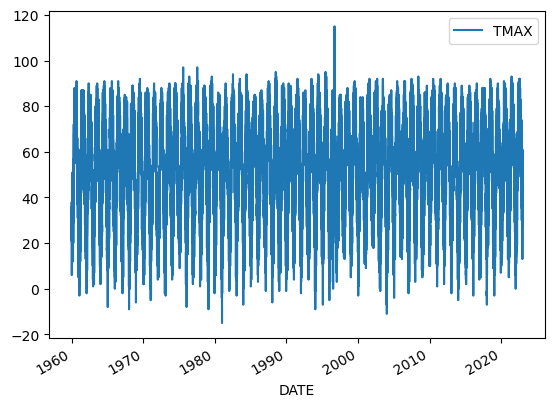

In [6]:
### check how the data looks visually
montpelier_tmax_df.plot()


In [7]:
### select max temp as desired variable, create maxtemp_df
maxtemp_df = montpelier_tmax_df[['TMAX']]
maxtemp_df

,TMAX
DATE,
1960-01-01,26.0
1960-01-02,33.0
1960-01-03,38.0
1960-01-04,32.0
1960-01-05,25.0
...,...
2022-12-28,31.0
2022-12-29,47.0
2022-12-30,58.0


In [8]:
%store maxtemp_df montpelier_tmax_df

Stored 'maxtemp_df' (DataFrame)
Stored 'montpelier_tmax_df' (DataFrame)


**Convert the Units**
In this next section I converted the temperature units from Farhenheit to Celcius. 

In [9]:
### rename max temp column to include units

maxtemp_units_df = maxtemp_df.rename (columns={
    'TMAX':'maxtemp_f',
})
maxtemp_units_df

,maxtemp_f
DATE,
1960-01-01,26.0
1960-01-02,33.0
1960-01-03,38.0
1960-01-04,32.0
1960-01-05,25.0
...,...
2022-12-28,31.0
2022-12-29,47.0
2022-12-30,58.0


In [10]:
### convert fahrenheit to celcius
maxtemp_units_df['maxtemp_c']=(maxtemp_units_df['maxtemp_f']-32)*(5/9)
maxtemp_units_df


,maxtemp_f,maxtemp_c
DATE,,
1960-01-01,26.0,-3.333333
1960-01-02,33.0,0.555556
1960-01-03,38.0,3.333333
1960-01-04,32.0,0.000000
1960-01-05,25.0,-3.888889
...,...,...
2022-12-28,31.0,-0.555556
2022-12-29,47.0,8.333333
2022-12-30,58.0,14.444444


In [11]:
%store maxtemp_units_df

Stored 'maxtemp_units_df' (DataFrame)


**Plot Results**
In this next section I ran code to plot my data. I was able to change the appearance of the plot and then manipulate the data to show annual mean data as opposed to daily data which makes the plot much easier to read. I also made an interactive plot. 

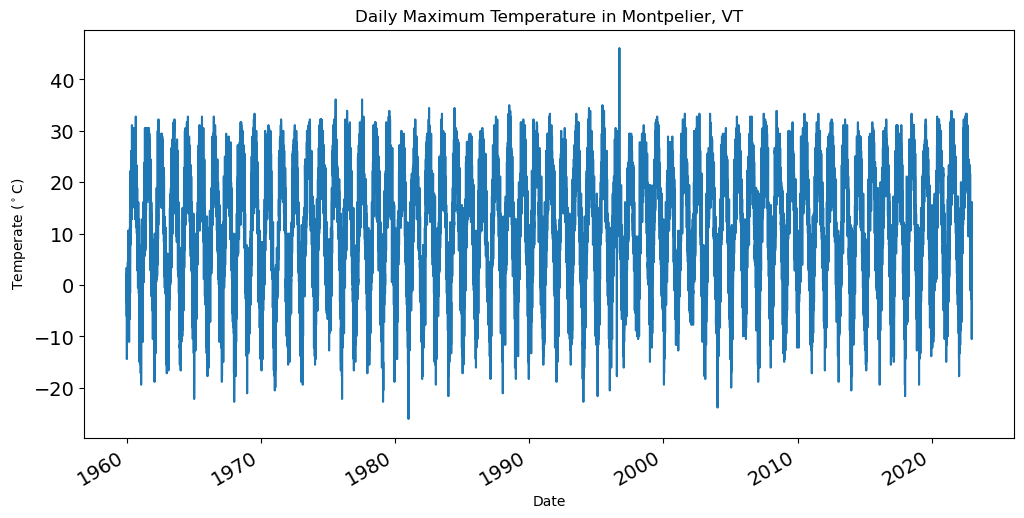

In [ ]:
### clean up plot using .plot

### plot without the legend, add title and axis labels, change font size and figure size
no_legend = maxtemp_units_df.plot( y = 'maxtemp_c',
    title = 'Daily Maximum Temperature in Montpelier, VT',
    xlabel = 'Date',
    ylabel = 'Temperate ($^\circ$C)',
    figsize = (12,6),
    fontsize = 14
)
no_legend.legend().remove()

In [13]:
### Clean Up Plot by Resampling
### Get mean Max Temp
annual_maxtemp_df = (
    ### resample data frame
    maxtemp_units_df

    ### sample annually
    .resample('YS')

    ### calculate mean
    .mean()
)
annual_maxtemp_df

,maxtemp_f,maxtemp_c
DATE,,
1960-01-01,52.095890,11.164384
1961-01-01,52.192308,11.217949
1962-01-01,51.304110,10.724505
1963-01-01,51.298630,10.721461
1964-01-01,52.676712,11.487062
...,...,...
2019-01-01,51.819178,11.010654
2020-01-01,54.912568,12.729205
2021-01-01,55.418733,13.010407


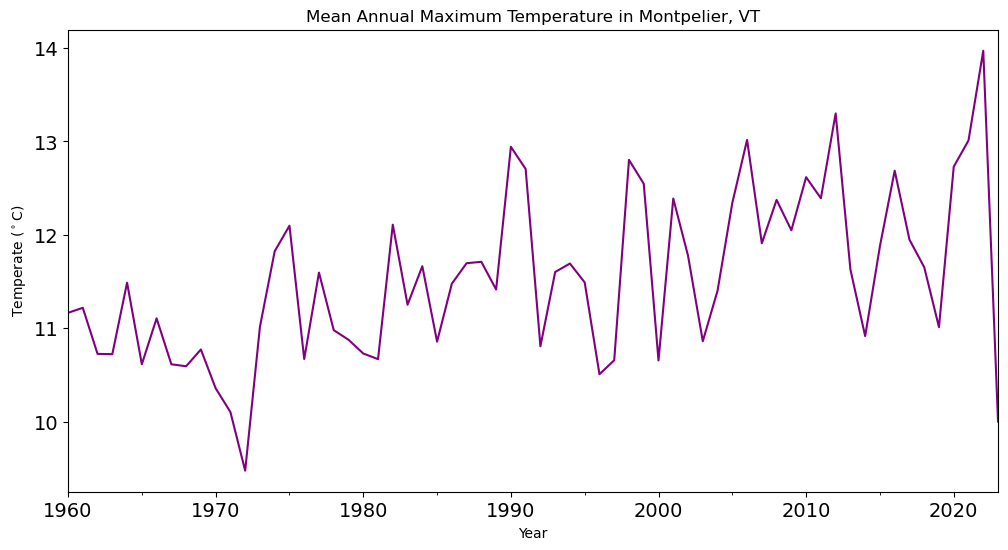

In [14]:
### Plot the annual data
no_legend = annual_maxtemp_df.plot( y = 'maxtemp_c',
    title = 'Mean Annual Maximum Temperature in Montpelier, VT',
    xlabel = 'Year',
    ylabel = 'Temperate ($^\circ$C)',
    figsize = (12,6),
    color = 'purple',
    fontsize = 14
)
no_legend.legend().remove()

In [15]:
### Make an interactive plot
hvplot.extension("bokeh")

### plot the annual data interactively
annual_maxtemp_plot=annual_maxtemp_df.hvplot (
    y = 'maxtemp_c',
    title = 'Mean Annual Maximum Temperature in Montpelier, VT',
    xlabel = 'Year',
    ylabel = 'Temperate (degrees Celcius)',
    fontsize = 14,
    color = 'purple',    
)

### view the plot
annual_maxtemp_plot


:Curve   [DATE]   (maxtemp_c)

In [16]:
### Save HV Plot
hv.save(annual_maxtemp_plot, 'annual_temp_plot.html')

In [17]:
%store annual_maxtemp_df


Stored 'annual_maxtemp_df' (DataFrame)


**Climate Trend Line**
In this section I imported additional packages to allow me to run an OLS linear regression on my data in order to be able to fit a trend line to the plot to better interperet the trend over time. 

In [ ]:
### advanced options on matplotlib/seaborn/pandas plots
import matplotlib.pyplot as plt

### common statistical plots for tabular data
import seaborn as sns

### fit an OLS linear regression
from sklearn.linear_model import LinearRegression

In [ ]:

### select celcius as desired variable, create annual_temp_c_df
annual_maxtemp_c_df = annual_maxtemp_df[['maxtemp_c']]
annual_maxtemp_c_df

,maxtemp_c
DATE,
1960-01-01,11.164384
1961-01-01,11.217949
1962-01-01,10.724505
1963-01-01,10.721461
1964-01-01,11.487062
...,...
2019-01-01,11.010654
2020-01-01,12.729205
2021-01-01,13.010407


In [ ]:
### Drop NA values
complete_montpelier_data_df=annual_maxtemp_c_df.dropna()
complete_montpelier_data_df

,maxtemp_c
DATE,
1960-01-01,11.164384
1961-01-01,11.217949
1962-01-01,10.724505
1963-01-01,10.721461
1964-01-01,11.487062
...,...
2019-01-01,11.010654
2020-01-01,12.729205
2021-01-01,13.010407


In [ ]:
### fit an OLS Linear Regression to the data

### define independent variable
### reshape 'year' to be a 2D array for scikit-learn
ind_variable = complete_montpelier_data_df.index.year.values.reshape(-1, 1)
ind_variable

### define dependent variable
dep_variable = complete_montpelier_data_df
dep_variable

### make linear regression model
model = LinearRegression()

### fit the model on the data
model.fit(ind_variable, dep_variable)

### calculate and print metrics
print(f'Slope: {model.coef_[0]} degrees per year')

Slope: [0.02573215] degrees per year


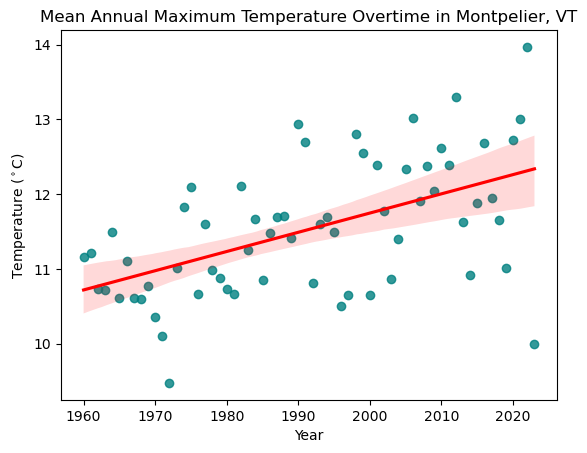

In [ ]:
### plot data
ax = sns.regplot(
    x = annual_maxtemp_c_df.index.year, 
    y = annual_maxtemp_c_df.maxtemp_c,

    ### change color of points
    color = 'teal',

    ### change appearance of trend line
    line_kws={'color':'red'}
)

### make labels
ax.set(
    title = 'Mean Annual Maximum Temperature Overtime in Montpelier, VT',
    xlabel = 'Year',
    ylabel = 'Temperature ($^\circ$C)'
)

### save your plot
plt.savefig('/workspaces/01-climate-fall-template/Montpelier_temperature_trend.jpeg')

### plot it
plt.show()